In [151]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
#导入多元正态分布,用于多维数据
#这个库建立在numpy之上,具有更高级的功能 这里导入统计学模块
from scipy.stats import multivariate_normal 

In [153]:
#创建二维数组
np.random.seed(0)
mean = [4,3]
cov = [[1,0.5],
       [0.5,1]]
data = np.random.multivariate_normal(mean,cov,300) #这是numpy自带的,还没用到scipy
cov_used = np.array(cov)

In [155]:
#马氏距离自定义函数
def mahalanobis_distance(x,mean,cov_inv):
    delta = x - mean
    return np.sqrt(np.dot(np.dot(delta,cov_inv),delta.T))

In [157]:
#网络数据
x,y = np.meshgrid(
    np.linspace(0,10,100),
    np.linspace(0,10,100),)
#ravel展开为1D数组
pos = np.c_[x.ravel(),y.ravel()]

In [159]:
#计算马氏距离
cov_inv = np.linalg.inv(cov_used)

Mahal_dd = np.diag((pos - mean) @ cov_inv @ (pos - mean).T)
Mahal_dd = np.sqrt(Mahal_dd)
Mahal_dd = np.reshape(Mahal_dd,x.shape)

In [161]:
Xc = data - mean

In [229]:
#构建可视化函数
def visualize_2d(x_cf,y_cf,x_sc,y_sc,theta = 0):
    fig,ax = plt.subplots(figsize = (6,6))
    
    plt.contourf(x_cf,y_cf,Mahal_dd,cmap = 'YlGnBu_r',levels = np.linspace(0,3,13))
    
    ax = sns.scatterplot(x = x_sc,y = y_sc,
                         marker = 'o',zorder = 1e3,
                         color = 'k',size = 3)
    if theta == np.pi/4:
        plt.plot(z1_2D[:,0],z1_2D[:,1],marker = 'x',markersize = 3,color = 'k')
        plt.plot(([i for (i,j) in z1_2D],[i for (i,j) in Xc]),
                 ([j for (i,j) in z1_2D],[j for (i,j) in Xc]),c = [0.6,0.6,0.6])

    elif theta == -np.pi/4:
        plt.plot(z2_2D[:,0],z2_2D[:,1],marker = 'x',markersize = 3,color = 'k')
        plt.plot(([i for (i,j) in z2_2D],[i for (i,j) in Xc]),
                 ([j for (i,j) in z2_2D],[j for (i,j) in Xc]),c = [0.6,0.6,0.6])
    
    ax.axvline(x = 0,c = 'k')
    ax.axhline(y = 0,c = 'k')
    ax.axvline(x = data[:,0].mean(),c = 'k')
    ax.axhline(y = data[:,1].mean(),c = 'k')
    ax.axis('scaled')
    ax.set_xbound(lower = x_sc.min(),upper = x_sc.max())
    ax.set_ybound(lower = y_sc.min(),upper = y_sc.max())
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])

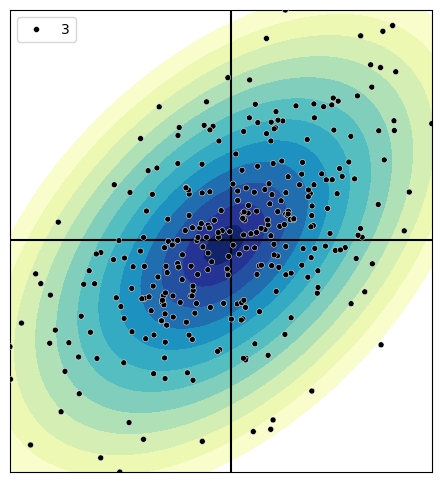

In [231]:
visualize_2d(x,y,x_sc = data[:,0],y_sc = data[:,1])

In [233]:
#中心化数据

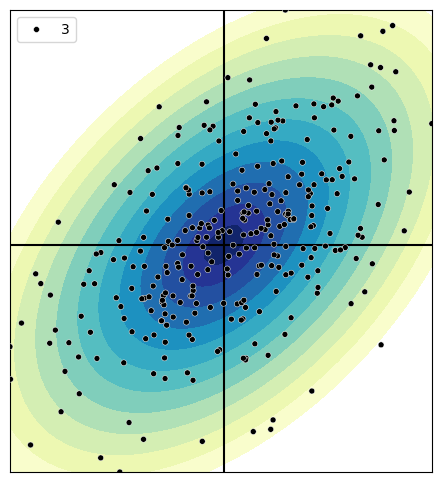

In [235]:
visualize_2d(x - mean[0],y-mean[1],x_sc = Xc[:,0],y_sc = Xc[:,1])

In [237]:
eig_values,V = np.linalg.eig(cov)

In [239]:
eig_values

array([1.5, 0.5])

In [241]:
V

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [243]:
Lambda = np.diag(eig_values)
Lambda

array([[1.5, 0. ],
       [0. , 0.5]])

In [245]:
theta = np.pi/4
v1 = np.array([[np.cos(theta)],
               [np.sin(theta)]])
#变成右乘了,所以和列向量左乘是相反的,每个点都是行向量了
#整个转置左乘变成右乘,投影矩阵也要跟着转置,相应的构成投影矩阵的投影向量也要转置
T1 = v1@v1.T
z1_1D = Xc@v1
z1_2D = Xc@T1

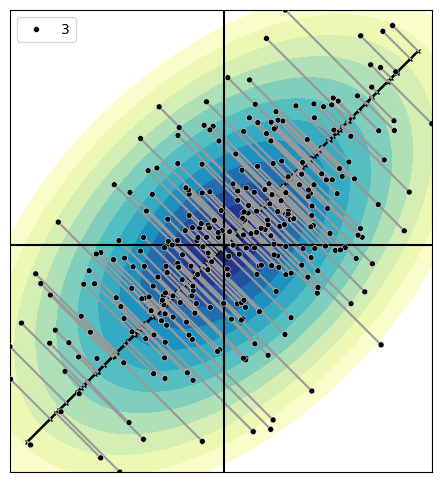

In [247]:
visualize_2d(x - mean[0],y-mean[1],x_sc = Xc[:,0],y_sc = Xc[:,1],theta = theta)

In [253]:
theta = -np.pi/4
v2 = np.array([[np.cos(theta)],
               [np.sin(theta)]])
T2 = v2@v2.T

z2_1D = Xc@v2
z2_2D = Xc@T2

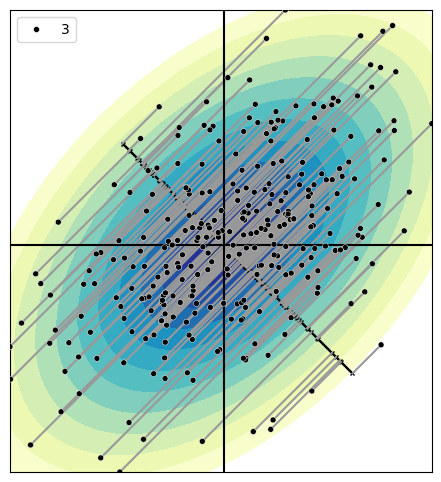

In [255]:
visualize_2d(x - mean[0],y-mean[1],x_sc = Xc[:,0],y_sc = Xc[:,1],theta = theta)